In [14]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [3]:
! pip install mlxtend

In [4]:
f = open('baskets.csv', encoding='cp1251')
dataset = f.read().split('\n')
f.close()

In [5]:
transactions = []
for s in dataset:
    transactions.append(s.split(','))
print(transactions)

[['креветки', 'миндаль', 'авокадо', 'овощная смесь', 'зеленый виноград', 'цельнозерновая мука', 'батат', 'творог', 'энергетический напиток', 'томатный сок', 'низкокалорийный йогурт', 'зеленый чай', 'мед', 'салат', 'минеральная вода', 'лосось', 'ягодный сок', 'замороженный смузи', 'шпинат', 'оливковое масло'], ['гамбургер', 'фрикадельки', 'яйца'], ['чатни'], ['индейка', 'авокадо'], ['минеральная вода', 'молоко', 'энергетический батончик', 'рис', 'зеленый чай'], ['низкокалорийный йогурт'], ['цельнозерновые макароны', 'картофель-фри'], ['суп', 'низкокалорийный крем', 'лук-шалот'], ['замороженные овощи', 'макароны', 'зеленый чай'], ['картофель-фри'], ['яйца', 'корм для животных'], ['печенье'], ['индейка', 'гамбургер', 'минеральная вода', 'яйца', 'растительное масло'], ['макароны', 'шампанское', 'печенье'], ['минеральная вода', 'лосось'], ['минеральная вода'], ['креветки', 'шоколад', 'курица', 'мед', 'масло', 'растительное масло', 'низкокалорийный йогурт'], ['индейка', 'яйца'], ['индейка', 

In [7]:
transactions_1 = transactions.pop(-1)

In [8]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder

In [9]:
encoder = TransactionEncoder()
encoded_array = encoder.fit(transactions).transform(transactions)
df_itemsets = pd.DataFrame(encoded_array, columns=encoder.columns_)

In [10]:
print('Number of transactions: ', len(transactions))
print('Number of unique items: ', len(set(sum(transactions, []))))

Number of transactions:  7500
Number of unique items:  115


In [11]:
df_itemsets

,авокадо,аксессуары,баклажаны,батат,батончик без глютена,бекон,белое вино,белый сыр,блинчики,ветчина,...,чили,шампанское,шампунь,шоколад,шпинат,энергетический батончик,энергетический напиток,эскалоп,ягодный сок,яйца
0,True,False,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
7496,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7497,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7498,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [12]:
from mlxtend.frequent_patterns import apriori
frequent_itemsets = apriori(df_itemsets, min_support=0.1, use_colnames=True)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [15]:
frequent_itemsets

,support,itemsets
0,0.132133,(зеленый чай)
1,0.170933,(картофель-фри)
2,0.188000,(макароны)
3,0.238400,(минеральная вода)
4,0.129600,(молоко)
5,0.163867,(шоколад)
6,0.179600,(яйца)


In [16]:
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda itemset:len(itemset))

In [17]:
print(frequent_itemsets[frequent_itemsets['length'] <= 7])

    support            itemsets  length
0  0.132133       (зеленый чай)       1
1  0.170933     (картофель-фри)       1
2  0.188000          (макароны)       1
3  0.238400  (минеральная вода)       1
4  0.129600            (молоко)       1
5  0.163867           (шоколад)       1
6  0.179600              (яйца)       1


## FP-Glow

In [18]:
from mlxtend.frequent_patterns import fpgrowth
frequent_itemsets_2 = fpgrowth(df_itemsets, min_support=0.1, use_colnames=True)

In [19]:
frequent_itemsets_2

,support,itemsets
0,0.238400,(минеральная вода)
1,0.132133,(зеленый чай)
2,0.179600,(яйца)
3,0.129600,(молоко)
4,0.170933,(картофель-фри)
5,0.188000,(макароны)
6,0.163867,(шоколад)


In [20]:
frequent_itemsets_2['length'] = frequent_itemsets_2['itemsets'].apply(lambda itemset:len(itemset))

In [21]:
print(frequent_itemsets_2[frequent_itemsets_2['length'] <=7])

    support            itemsets  length
0  0.238400  (минеральная вода)       1
1  0.132133       (зеленый чай)       1
2  0.179600              (яйца)       1
3  0.129600            (молоко)       1
4  0.170933     (картофель-фри)       1
5  0.188000          (макароны)       1
6  0.163867           (шоколад)       1


## Eclat

In [22]:
pip install pyECLAT

In [23]:
df = pd.DataFrame(transactions)
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,креветки,миндаль,авокадо,овощная смесь,зеленый виноград,цельнозерновая мука,батат,творог,энергетический напиток,томатный сок,низкокалорийный йогурт,зеленый чай,мед,салат,минеральная вода,лосось,ягодный сок,замороженный смузи,шпинат,оливковое масло
1,гамбургер,фрикадельки,яйца,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
2,чатни,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
3,индейка,авокадо,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
4,минеральная вода,молоко,энергетический батончик,рис,зеленый чай,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,блинчики,низкокалорийный майонез,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
7496,сливочное масло,низкокалорийный майонез,свежий хлеб,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
7497,гамбургер,замороженные овощи,яйца,картофель-фри,журнал,зеленый чай,None,None,None,None,None,None,None,None,None,None,None,None,None,None
7498,курица,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None


In [24]:
from pyECLAT import ECLAT
eclat_instance = ECLAT(data=df, verbose=True)

get_ECLAT_indexes, get_ECLAT_supports = eclat_instance.fit(min_support=0.1, verbose=True)

df = pd.DataFrame(get_ECLAT_supports.items(),columns=['itemsets', 'support'])
df

100%|██████████| 116/116 [00:00<00:00, 882.03it/s] 


Combination 1 by 1


7it [00:01,  4.96it/s]


Combination 2 by 2


21it [00:03,  6.14it/s]


Combination 3 by 3


35it [00:04,  8.14it/s]


,itemsets,support
0,макароны,0.188000
1,зеленый чай,0.132133
2,минеральная вода,0.238400
3,шоколад,0.163867
4,молоко,0.129600
5,картофель-фри,0.170933
6,яйца,0.179600


In [25]:
df['length'] = df['itemsets'].apply(lambda itemset: len(itemset.split('&')))

In [26]:
print(df[df['length'] <=7])

           itemsets   support  length
0          макароны  0.188000       1
1       зеленый чай  0.132133       1
2  минеральная вода  0.238400       1
3           шоколад  0.163867       1
4            молоко  0.129600       1
5     картофель-фри  0.170933       1
6              яйца  0.179600       1


# Сравнение Apriori, FP-Glow

---



In [28]:
import time as t
from pyECLAT import ECLAT

supports = [0.05, 0.1, 0.15, 0.2]

eclat_instance = ECLAT(data=pd.DataFrame(transactions), verbose=False)

min_supp = min(supports)
_, eclat_supports_all = eclat_instance.fit(min_support=min_supp, verbose=False)

times_1 = []
times_2 = []
times_3 = []

results_1 = []
results_2 = []
results_3 = []

for supp in supports:
    # Apriori
    st_time = t.time() * 1000
    apr_res = apriori(df_itemsets, min_support=supp, use_colnames=True)
    apr_res = apr_res[apr_res['itemsets'].apply(lambda x: len(x) <= 7)]
    results_1.append(len(apr_res))
    times_1.append(t.time() * 1000 - st_time)

    # FP-Growth
    st_time = t.time() * 1000
    fp_res = fpgrowth(df_itemsets, min_support=supp, use_colnames=True)
    fp_res = fp_res[fp_res['itemsets'].apply(lambda x: len(x) <= 7)]
    results_2.append(len(fp_res))
    times_2.append(t.time() * 1000 - st_time)

    # ECLAT — фильтруем уже найденные наборы
    st_time = t.time() * 1000
    eclat_filtered = {k: v for k, v in eclat_supports_all.items()
                      if v >= supp and len(k.split('&')) <= 7}
    results_3.append(len(eclat_filtered))
    times_3.append(t.time() * 1000 - st_time)

print("Times Apriori: ", times_1)
print("Times FP-Growth: ", times_2)
print("Times ECLAT: ", times_3)

print("Results Apriori: ", results_1)
print("Results FP-Growth: ", results_2)
print("Results ECLAT: ", results_3)


Times Apriori:  [14.8828125, 3.9619140625, 3.50927734375, 3.057373046875]
Times FP-Growth:  [269.618896484375, 44.74169921875, 43.1015625, 40.47265625]
Times ECLAT:  [0.0830078125, 0.0185546875, 0.015625, 0.015380859375]
Results Apriori:  [28, 7, 5, 1]
Results FP-Growth:  [28, 7, 5, 1]
Results ECLAT:  [28, 7, 5, 1]


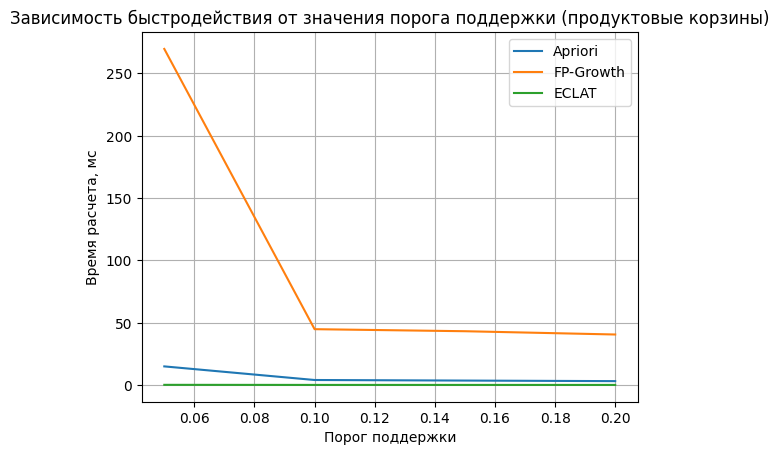

In [35]:
import matplotlib.pyplot as plot

plot.plot(supports, times_1, label='Apriori')
plot.plot(supports, times_2, label='FP-Growth')
plot.plot(supports, times_3, label='ECLAT')  # добавили ECLAT

plot.title("Зависимость быстродействия от значения порога поддержки (продуктовые корзины)")
plot.xlabel("Порог поддержки")
plot.ylabel("Время расчета, мс")
plot.legend()
plot.grid(True)
plot.show()


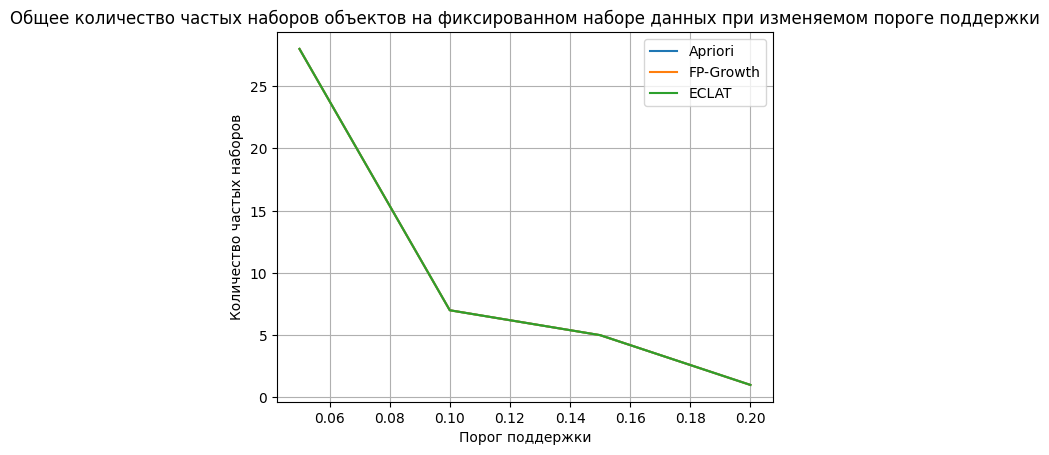

In [36]:
import matplotlib.pyplot as plot

plot.plot(supports, results_1, label='Apriori')
plot.plot(supports, results_2, label='FP-Growth')
plot.plot(supports, results_3, label='ECLAT')

plot.title("Общее количество частых наборов объектов на фиксированном наборе данных при изменяемом пороге поддержки")
plot.xlabel("Порог поддержки")
plot.ylabel("Количество частых наборов")
plot.legend()
plot.grid(True)
plot.show()


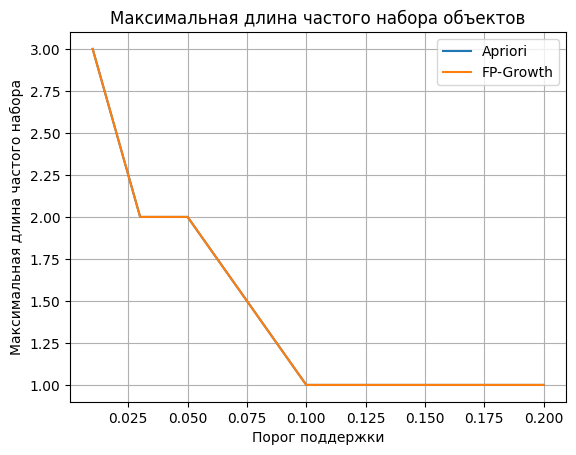

In [40]:
supports = [0.01, 0.03, 0.05, 0.1, 0.15, 0.20]
apriori_lengths = [max(len(itemset) for itemset in apriori(df_itemsets, min_support=sup, use_colnames=True)['itemsets']) for sup in supports]
fp_growth_lengths = [max(len(itemset) for itemset in fpgrowth(df_itemsets, min_support=sup, use_colnames=True)['itemsets']) for sup in supports]

plot.plot(supports, apriori_lengths, label='Apriori')
plot.plot(supports, fp_growth_lengths, label='FP-Growth')
plot.xlabel('Порог поддержки')
plot.ylabel('Максимальная длина частого набора')
plot.title('Максимальная длина частого набора объектов')
plot.legend()
plot.grid(True)
plot.show()